# Dynamic portfolio choice with CRRA utility and Markov return dynamics

## Introduction

We implement a finite-horizon dynamic portfolio choice problem with one risky asset and one risk-free asset under constant relative risk aversion (CRRA) preferences. The risky asset follows a non-recombining binomial return process (i.e., binomial tree), so in each period its return is either an up return $u$ or a down return $d$, while the risk-free asset yields a certain return $r_f$.

Unlike the standard i.i.d. binomial model, the probability of an up move is allowed to depend on the previous period’s realized direction through a two-state Markov structure. In particular, the model uses transition probabilities:

$$
P(s_{t+1}=u \mid s_t=u)=p_{uu} \qquad
P(s_{t+1}=u \mid s_t=d)=p_{du}
$$

$$
P(s_{t+1}=D \mid s_t=u)=1-p_{uu} \qquad
P(s_{t+1}=D \mid s_t=d)=1-p_{du}
$$


This allows the return process to exhibit **momentum** when $p_{uu}>p_{du}$, or **mean reversion** when $p_{uu}<p_{du}$. The investor chooses in each period the fraction $x_t$ of wealth invested in the risky asset to maximize expected utility of terminal wealth over a fixed horizon.

The theory is based on dynamic programming and the Bellman principle of optimality. If $W_t$ is wealth at time $t$, then the one-period wealth evolution is:

$$
W_{t+1}=W_t\left[x_t r_{t+1} + (1-x_t)r_f\right]
$$

Preferences are represented by CRRA utility,

$$
U(W)=
\begin{cases}
\dfrac{W^{1-\gamma}}{1-\gamma}, & \gamma \neq 1 \\[6pt]
\log W, & \gamma = 1
\end{cases}
$$

where $\gamma$ is the coefficient of relative risk aversion. The investor’s objective is:

$$
\max_{\{x_t\}} \; \mathbb{E}\big[U(W_T)\big]
$$

A key theoretical simplification comes from the homotheticity of CRRA utility. Because wealth enters multiplicatively in the law of motion, the value function can be written as:

$$
V_t(W_t,s_t)=\frac{W_t^{\,1-\gamma}}{1-\gamma}\,A_t(s_t)
$$

where $s_t\in\{u,d\}$ is the state variable summarizing the most recent return direction, and $A_t(s_t)$ is a continuation-value coefficient. This means that current wealth does not need to be treated as a separate state variable: under CRRA, the optimal risky share depends only on time and the Markov return state. Substituting this form into the Bellman equation gives the recursion:

$$
V_t(W_t,s_t)=\max_{x_t}\;
\mathbb{E}_t\left[
V_{t+1}\!\left(W_t\big(x_tr_{t+1}+(1-x_t)r_f\big),s_{t+1}\right)
\right]
$$

Using the homothetic representation, this reduces to:

$$
A_t(s_t)=\max_{x_t}
\mathbb{E}_t\left[
\big(x_tr_{t+1}+(1-x_t)r_f\big)^{1-\gamma}
A_{t+1}(s_{t+1})
\;\middle|\; s_t
\right]
$$

This recursion is what the code solves by backward induction. For the 'up' state, the Bellman step becomes:

$$
A_t(u)=\max_x \left[
p_{uu}\big(xu+(1-x)r_f\big)^{1-\gamma}A_{t+1}(u)
+
(1-p_{uu})\big(xd+(1-x)r_f\big)^{1-\gamma}A_{t+1}(d)
\right]
$$

and for the 'down' state:

$$
A_t(d)=\max_x \left[
p_{du}\big(xu+(1-x)r_f\big)^{1-\gamma}A_{t+1}(u)
+
(1-p_{du})\big(xd+(1-x)r_f\big)^{1-\gamma}A_{t+1}(d)
\right]
$$

At time $0$, before any move has been observed, the code uses an initial up probability $p_{0,\mathrm{up}}$, so the initial optimization is:

$$
\max_x \left[
p_{0,\mathrm{up}}\big(xu+(1-x)r_f\big)^{1-\gamma}A_1(u)
+
(1-p_{0,\mathrm{up}})\big(xd+(1-x)r_f\big)^{1-\gamma}A_1(d)
\right]
$$

Methodologically, the notebook discretizes the feasible portfolio weights over a grid and evaluates the Bellman objective at each grid point. At every date and state, it selects the risky weight that maximizes expected continuation value and stores it as the optimal policy. After solving the problem backward, it propagates state probabilities forward using the Markov transition rule to construct the expected allocation path and expected wealth path. In this way, the framework combines recursive portfolio optimization, CRRA preferences, and state-dependent return dynamics to show how optimal asset allocation changes when return predictability, momentum, or mean reversion are introduced.

**Note:** For those familiar with option pricing, dynamic programming operates on a similar intuition to American options. In options, the goal is to determine the optimal time to exercise, whereas in asset allocation, the focus shifts to identifying the optimal portfolio weights.


## Exercise

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [2]:
# Define certainty equivalent return:
'''
This will be used later to compare the benefit of a dynamic allocation approach
vs. a fix-mix strategy and a 1-period myopic portfolio.
Note: Assumes CRRA utility.
'''

def cert_equiv_ret(U_star, gamma, T):
    return np.log((1 - gamma) * U_star) / (T * (1 - gamma))

In [3]:
# Inputs:
# =========================

NumSteps = 5
gamma = 2
accuracy = 0.001 # for weights

# Risky asset returns:
r_u = 0.38
r_d = -0.18

# Risk-free rate
rf = 0.02

# Initial probability that the first move is 'up' or 'down'
p_0_u = 0.50
p_0_d = 1 - p_0_u

# Markov transition probabilities
p_u_u = 0.60 # Probability of 'up' given just seen 'up'
p_d_u = 1 - p_u_u # Probability of 'down' given just seen 'up'
p_u_d = 0.40
p_d_d = 1 - p_u_d


In [4]:
# Binomial lattice (non-recombining) approach:
# =========================

# Create returns matrix
r_all = np.full((2**NumSteps, NumSteps), np.nan)

for i in range(1, NumSteps + 1):
    r_step = np.tile(np.array([r_u, r_d]), 2**(i - 1))
    r_all[:len(r_step), i - 1] = r_step

# Create probabilities matrix
p_all = np.full((2**NumSteps, NumSteps), np.nan)
p_all[:2, 0] = np.array([p_0_u, p_0_d])

for i in range(2, NumSteps + 1):
    p_step = np.tile(np.array([p_u_u, p_d_u, p_u_d, p_d_d]), 2**(i - 2))
    p_all[:len(p_step), i - 1] = p_step
    

In [5]:
# Cumulative probabilities:
# =========================

idx_p = np.full((2**NumSteps, NumSteps), np.nan)

for i in range(1, NumSteps + 1):
    temp_p = np.tile(np.arange(1, 2**i + 1), (2**(NumSteps - i), 1))
    idx_p[:, i - 1] = temp_p.reshape(-1, order="F")

offsets = np.arange(0, 2**NumSteps * NumSteps, 2**NumSteps)
idx_p = idx_p + offsets
idx_p = idx_p.astype(int) - 1

p_all_flat = p_all.reshape(-1, order="F")

p_terminal = np.zeros((2**NumSteps, NumSteps))
for i in range(2**NumSteps):
    p_terminal[i, :] = np.cumprod(p_all_flat[idx_p[i, :]])

p_terminal_dash = np.full((2**(NumSteps - 1), NumSteps - 1), np.nan)
for i in range(1, NumSteps):
    step_size = 2**(NumSteps - i)
    p_temp = p_terminal[::step_size, i - 1]
    p_terminal_dash[:len(p_temp), i - 1] = p_temp
    

In [6]:
# 1. Myopic/Merton Fraction approach:
# =========================

def fun_myopic(x):
    w = x[0]
    U_up = ((1 + (w * r_u) + ((1 - w) * rf)) ** (1 - gamma)) / (1 - gamma)
    U_down = ((1 + (w * r_d) + ((1 - w) * rf)) ** (1 - gamma)) / (1 - gamma)
    Exp_U = p_0_u * U_up + p_0_d * U_down
    return -Exp_U

res_myopic = minimize(fun_myopic, x0=np.array([0.5]), bounds=[(0, 1)], method="SLSQP")

w_myopic_opt = res_myopic.x[0]
U_star_myopic = res_myopic.fun

# Certainty equivalent computation
CE_myopic = cert_equiv_ret(-U_star_myopic, gamma, 1)


In [7]:
# 2. Fix-mix strategy approach:
# =========================

# Create possible permutations of up and down returns
idx_up = np.array([
    [c == "1" for c in format(x, f"0{NumSteps}b")]
    for x in range(2**NumSteps - 1, -1, -1)])

r_vec = np.full((2**NumSteps, NumSteps), np.nan)
for i in range(2**NumSteps):
    idx_up_i = idx_up[i, :]
    r_vec[i, idx_up_i] = r_u
    r_vec[i, ~idx_up_i] = r_d

def fun_fm(x):
    w = x[0]
    W_T = np.prod(1 + (w * r_vec) + ((1 - w) * rf), axis=1)
    return np.sum((-(W_T ** (1 - gamma)) / (1 - gamma)) * p_terminal[:, -1])

res_fm = minimize(fun_fm, x0=np.array([0.5]), bounds=[(0, 1)], method="SLSQP")

w_fm_opt = res_fm.x[0]
U_star_fm = res_fm.fun

# Certainty equivalent computation
CE_fm = cert_equiv_ret(-U_star_fm, gamma, NumSteps)


In [8]:
# 3. Solve dynamic programming problem:
# =========================

# Define weights grid
w = np.arange(0, 1 + accuracy / 2, accuracy)

# Pre-allocation
U_star = np.ones((2**NumSteps, 1))
Wopt = np.full((2**(NumSteps - 1), NumSteps), np.nan)

# Loop backwards through tree
for t in range(NumSteps, 0, -1):

    # Create weights grid
    w_mat = np.tile(w, (2**t, 1))

    # Select returns and probabilities for this period
    r_t = r_all[:2**t, t - 1].reshape(-1, 1)
    p_t = p_all[:2**t, t - 1].reshape(-1, 1)

    # Compute the expected continuation utility at time t for every candidate portfolio weight
    wealth = (w_mat * (1 + r_t)) + ((1 - w_mat) * (1 + rf))
    utility = U_star * (wealth ** (1 - gamma)) / (1 - gamma)
    utility_p = utility * p_t

    #Sum the two child branches to get conditional expected utility
    exp_utility = utility_p.reshape(2, utility_p.shape[0] // 2, len(w), order="F").sum(axis=0)

    # Find the weights which maximize expected utility
    if t > 1:
        idxW = np.argmax(exp_utility, axis=1)
    else:
        idxW = np.array([np.argmax(exp_utility)])
        U_star_t_1 = np.max(exp_utility)

    # Save the weights
    Wopt_t = w[idxW]
    Wopt[:len(idxW), t - 1] = Wopt_t

    # Duplicate each optimal weight and then stack the columns into one column vector
    W_opt_t = np.repeat(Wopt_t, 2).reshape(-1, 1)

    # Compute the utility contribution of the optimal weight choice
    wealth_opt = (W_opt_t * (1 + r_t)) + ((1 - W_opt_t) * (1 + rf))
    utility_opt = U_star * (wealth_opt ** (1 - gamma))
    utility_opt_p = utility_opt * p_t
    
    U_star = utility_opt_p.reshape(2, utility_opt_p.size // 2, order="F").sum(axis=0).reshape(-1, 1)

# Prob-weighted average asset allocation through time (glidepath)
Wopt_avg = np.concatenate(([Wopt[0, 0]], np.nansum(Wopt[:, 1:] * p_terminal_dash, axis=0)))

# Certainty equivalent computation
CE_dynamic = cert_equiv_ret(U_star_t_1, gamma, NumSteps)


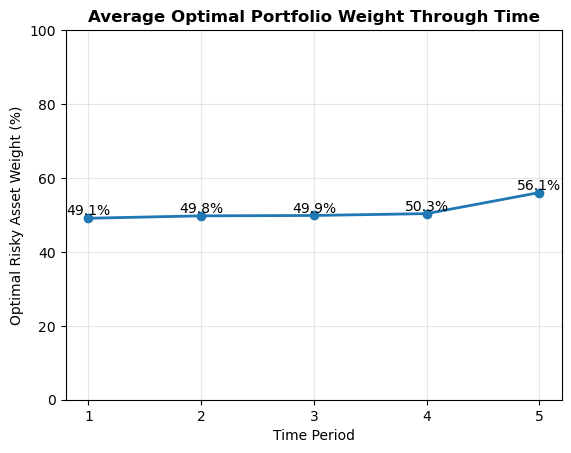

In [9]:
# Plot optimal expected evolution of risky asset weight:

x = np.arange(1, len(Wopt_avg) + 1)

plt.plot(x, Wopt_avg*100, linewidth=2, marker="o")

for xi, yi in zip(x, Wopt_avg*100):
    plt.text(xi, yi, f"{yi:.1f}%", ha="center", va="bottom")

plt.xlabel("Time Period")
plt.ylabel("Optimal Risky Asset Weight (%)")
plt.title("Average Optimal Portfolio Weight Through Time", fontweight="bold")
plt.grid(True, alpha=0.3)
plt.xticks(x)
plt.ylim(0, 100)
plt.show()

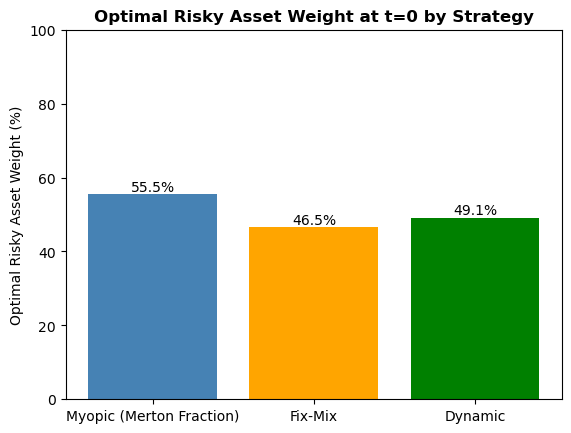

In [10]:
# Plot the optimal weight results:

weights = [w_myopic_opt * 100, w_fm_opt * 100, Wopt_avg[0] * 100]
labels = ["Myopic (Merton Fraction)", "Fix-Mix", "Dynamic"]
colors = ["steelblue", "orange", "green"]

bars = plt.bar(labels, weights, color=colors)
plt.ylabel("Optimal Risky Asset Weight (%)")
plt.title("Optimal Risky Asset Weight at t=0 by Strategy", fontweight="bold")
plt.ylim(0, 100)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f"{height:.1f}%", ha='center', va='bottom')

plt.show()


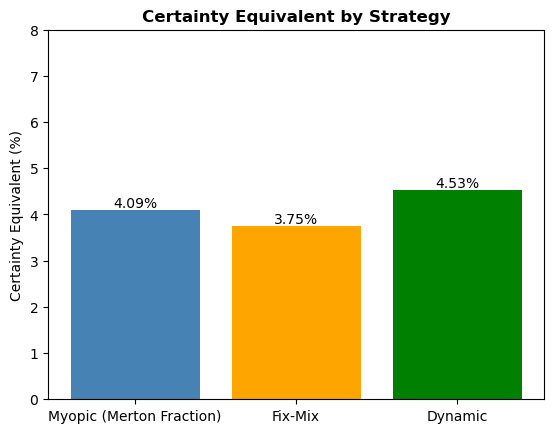

In [11]:
# Plot the certainty equivalent results:

ce_values = [CE_myopic * 100, CE_fm * 100, CE_dynamic * 100]
labels = ["Myopic (Merton Fraction)", "Fix-Mix", "Dynamic"]
colors = ["steelblue", "orange", "green"]

bars = plt.bar(labels, ce_values, color=colors)

plt.ylabel("Certainty Equivalent (%)")
plt.title("Certainty Equivalent by Strategy", fontweight="bold")
plt.ylim(0, 8)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f"{height:.2f}%", ha="center", va="bottom")

plt.show()

## Time for you to try

Use the code and see what the results look like when you change the 'up' and 'down' probabilities. In particular:

1) How does the optimal weight in the risky asset change if you assume mean-reversion or momentum?

2) Does the optimal weight in the risky asset increase if you increase the time horizon? What if you assume the risky asset return to be i.i.d.?

Hint: For more info on 'time diversification' see the following paper:
https://www.acsu.buffalo.edu/~keechung/Lecture%20Notes%20and%20Syllabus%20(MGF633)/What%20Practitioners%20Need%20to%20Know%20About%20Time%20Diversification.pdf